# Resistance-oriented generative models for MALDI-TOF spectra

This notebook studies whether generative latent-variable models can learn a representation of MALDI-TOF spectra that is useful for antimicrobial resistance (AMR) prediction.

The biological problem is the following. MALDI-TOF mass spectrometry measures the abundance of ionized molecular fragments, mainly abundant proteins and peptides, across a grid of mass-to-charge bins. In clinical microbiology, MALDI-TOF is routinely used for species identification because spectra contain reproducible taxonomic signatures. AMR, however, is more subtle: resistance is often caused by genes, plasmids, porin changes, beta-lactamases, efflux pumps or regulatory changes that are not always directly visible as one isolated peak. The working hypothesis of this project is therefore not that a single peak perfectly reveals resistance, but that resistance phenotypes may correlate with global spectral structure, strain background, clonal lineage, protein expression patterns or other biological covariates captured by the spectrum.

The modelling goal is to learn a latent variable `w` from the spectrum `x`:

$$
q_\phi(w \mid x),
$$

and then use `w` to predict the AMR profile:

$$
p_\theta(y \mid w).
$$

The true AMR vector `y` is never used as an input to the model. It is used only as a supervised target in the loss and as ground truth during evaluation. This is important because otherwise the model would leak the answer into the latent space and the AUC would not measure prediction from MALDI-TOF spectra.

The notebook is organised as a reproducible experiment:

1. Load and preprocess the MALDI-TOF/AMR dataset.
2. Train a baseline resistance-oriented VAE.
3. Add early stopping using validation global AUC.
4. Compare advanced VAE variants: IWAE, VampPrior, Gaussian mixture prior, VQ-VAE and implicit posterior VAE.
5. Report all models with the same validation/test protocol.


## 1. Imports and reproducibility

We use PyTorch for the neural models, scikit-learn for data splitting, AUC and t-SNE, NumPy for array manipulation and Matplotlib for visualisation.

Reproducibility is especially important here because the train/validation/test split and stochastic latent sampling affect AUC. The helper `set_seed` fixes the random seeds used by Python, NumPy and PyTorch.


In [1]:
import copy
import os
import pickle
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 42
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


Using device: cpu


## 2. Configuration

The project has two groups of hyperparameters.

The first group defines the biological task: the target bacterial species and antibiotics. We focus on *Klebsiella pneumoniae*, a clinically relevant Gram-negative pathogen where beta-lactam and carbapenem resistance are major hospital concerns. The selected antibiotics cover fluoroquinolone resistance, cephalosporin resistance, beta-lactam/beta-lactamase inhibitor response and carbapenem resistance.

The second group defines the model. The key loss weights are:

$$
\mathcal{J}
= \lambda_{AMR}\mathcal{L}_{AMR}
+ \lambda_{spec}\mathcal{L}_{spec}
+ \beta_w\mathcal{R}_{latent}.
$$

`LAMBDA_AMR` is deliberately larger than `LAMBDA_SPEC` because the main objective is AMR prediction from spectra, not perfect reconstruction. The reconstruction term is auxiliary: it keeps `w` connected to spectral structure while allowing `w` to be resistance-oriented.


In [2]:
DATA_PATH = "COMBINED_MARISMA_DRIAMS.pkl"
TARGET_SPECIES = "Klebsiella_Pneumoniae"

TARGET_ANTIBIOTICS = [
    "Ciprofloxacin",
    "Ceftriaxone",
    "Piperacillin-Tazobactam",
    "Cefepime",
    "Imipenem",
    "Meropenem",
]

LATENT_DIM_W = 64
ENC_H1 = 512
ENC_H2 = 128
DEC_Y_H = 64
DEC_X_H1 = 256
DEC_X_H2 = 1024

BATCH_SIZE = 64
EPOCHS = 100
LR = 1e-3
TEST_SIZE = 0.30
VALIDATION_SIZE = 0.20

EARLY_STOPPING_PATIENCE = 5
MIN_DELTA_AUC = 1e-4
RESTORE_BEST_MODEL = True

TOP_K_REMOVE = 0
EPS = 1e-8

LAMBDA_AMR = 5.0
LAMBDA_SPEC = 0.05
BETA_W = 1e-4

ADVANCED_EPOCHS = 100
ADVANCED_PATIENCE = 5
RUN_ADVANCED_EXPERIMENTS = True

IWAE_K = 5
VAMP_NUM_PSEUDO_INPUTS = 20
GM_NUM_COMPONENTS = 8
VQ_NUM_CODES = 64
VQ_COMMITMENT_BETA = 0.25
IMPLICIT_NOISE_DIM = 32
MMD_SIGMAS = [0.5, 1.0, 2.0, 4.0]

TSNE_PERPLEXITY = 30
TSNE_N_ITER = 1000


## 3. Data loading and biological preprocessing

The dataset is expected to contain:

- `data`: MALDI-TOF spectra with shape `[n_samples, n_mz_bins]`.
- `label`: species labels.
- `amr`: AMR labels, with missing values represented as `NaN`.
- `antibiotics`: names of the AMR columns.

MALDI-TOF spectra are sparse and peak-dominated. The optional `TOP_K_REMOVE` operation can remove the most intense peaks per spectrum. This is sometimes useful if the largest species-identification peaks dominate the signal and hide weaker phenotype-associated patterns. Here it is set to zero by default, so the raw processed spectra are preserved.

Missing AMR values are not imputed. They are masked in the loss and evaluation. This is preferable to filling unknown phenotypes with susceptible/resistant labels, which would introduce artificial supervision.


In [3]:
def remove_top_k_peaks_per_spectrum(X, top_k=10):
    """Set the top-k most intense peaks of each spectrum to zero."""
    X_new = X.copy()
    if top_k <= 0:
        return X_new
    for i in range(X_new.shape[0]):
        idx = np.argpartition(X_new[i], -top_k)[-top_k:]
        X_new[i, idx] = 0
    return X_new


def load_project_payload(data_path):
    with open(data_path, "rb") as f:
        payload = pickle.load(f)
    required_keys = {"data", "label", "amr", "antibiotics"}
    missing = required_keys.difference(payload)
    if missing:
        raise KeyError(f"Missing keys in payload: {sorted(missing)}")
    return payload


def select_species_and_antibiotics(payload, species, antibiotic_names, top_k_remove=0):
    X = remove_top_k_peaks_per_spectrum(payload["data"], top_k_remove)
    y_species = np.array(payload["label"])
    amr = payload["amr"]
    antibiotics = list(payload["antibiotics"])

    mask_species = y_species == species
    X = X[mask_species]
    amr = amr[mask_species]

    antibiotic_idx = [antibiotics.index(name) for name in antibiotic_names]
    amr = amr[:, antibiotic_idx].astype(np.float32)
    return X, amr


payload = load_project_payload(DATA_PATH)
print("Raw X shape:", payload["data"].shape)
print("Raw AMR shape:", payload["amr"].shape)
print("Num antibiotics in file:", len(payload["antibiotics"]))

X, amr = select_species_and_antibiotics(
    payload,
    species=TARGET_SPECIES,
    antibiotic_names=TARGET_ANTIBIOTICS,
    top_k_remove=TOP_K_REMOVE,
)

num_antibiotics = len(TARGET_ANTIBIOTICS)
input_dim = X.shape[1]

print("Filtered X shape:", X.shape)
print("Filtered AMR shape:", amr.shape)
print("Input spectrum dimension:", input_dim)
print("Target antibiotics:", TARGET_ANTIBIOTICS)
print("Missing AMR labels:", np.isnan(amr).sum())


Raw X shape: (66832, 6000)
Raw AMR shape: (66832, 104)
Num antibiotics in file: 104
Filtered X shape: (19265, 6000)
Filtered AMR shape: (19265, 6)
Input spectrum dimension: 6000
Target antibiotics: ['Ciprofloxacin', 'Ceftriaxone', 'Piperacillin-Tazobactam', 'Cefepime', 'Imipenem', 'Meropenem']
Missing AMR labels: 34457


## 4. Train/validation/test split and dataset object

The split has a methodological purpose:

- The training set updates the model parameters.
- The validation set chooses the best epoch by global AUC.
- The test set is kept untouched until final reporting.

This avoids selecting the model on the test set. In biomedical prediction tasks, that distinction matters because optimistic performance estimates can easily appear when the same held-out data are used repeatedly during model development.


In [4]:
class ResistanceSpectrumDataset(Dataset):
    def __init__(self, spectra, amr_targets):
        self.X = torch.tensor(spectra, dtype=torch.float32)
        self.y = torch.tensor(amr_targets, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_splits(X, y, test_size, validation_size, seed):
    all_idx = np.arange(len(X))
    train_val_idx, test_idx = train_test_split(
        all_idx,
        test_size=test_size,
        random_state=seed,
        shuffle=True,
    )
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=validation_size,
        random_state=seed,
        shuffle=True,
    )
    return train_idx, val_idx, test_idx


def make_loader(X_subset, y_subset, batch_size, shuffle):
    dataset = ResistanceSpectrumDataset(X_subset, y_subset)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=False)


train_idx, val_idx, test_idx = make_splits(X, amr, TEST_SIZE, VALIDATION_SIZE, SEED)

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
amr_train, amr_val, amr_test = amr[train_idx], amr[val_idx], amr[test_idx]

train_loader = make_loader(X_train, amr_train, BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, amr_val, BATCH_SIZE, shuffle=False)
test_loader = make_loader(X_test, amr_test, BATCH_SIZE, shuffle=False)

print("Train size     :", len(X_train))
print("Validation size:", len(X_val))
print("Test size      :", len(X_test))


Train size     : 10788
Validation size: 2697
Test size      : 5780


## 5. Shared neural building blocks

All models use the same high-level biological pathway:

$$
x \rightarrow w \rightarrow \hat{y},
\qquad
x \rightarrow w \rightarrow \hat{x}.
$$

The first path predicts AMR. The second reconstructs the spectrum and prevents the latent representation from becoming a purely discriminative shortcut. This is useful biologically because the representation should still describe spectral variation, not only memorize class boundaries.

The decoder has two branches:

1. **AMR branch**: outputs logits for the selected antibiotics.
2. **Spectrum branch**: outputs a hurdle-style reconstruction of the spectrum.

MALDI-TOF spectra are sparse: most m/z bins are zero or close to zero, while peaks carry the signal. The reconstruction therefore separates peak presence from positive intensity:

$$
p(x_j \mid w)
= p(s_j = 1 \mid w)\,p(x_j \mid s_j=1,w),
$$

where $s_j$ indicates whether bin $j$ contains a peak.


In [5]:
class SpectrumAMRDecoder(nn.Module):
    """Shared AMR and spectrum decoders used by all latent models."""

    def __init__(self, input_dim, num_antibiotics):
        super().__init__()
        self.dec_y = nn.Sequential(
            nn.Linear(LATENT_DIM_W, DEC_Y_H),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(DEC_Y_H, num_antibiotics),
        )
        self.dec_x = nn.Sequential(
            nn.Linear(LATENT_DIM_W, DEC_X_H1),
            nn.ReLU(),
            nn.Linear(DEC_X_H1, DEC_X_H2),
            nn.ReLU(),
        )
        self.presence_head = nn.Linear(DEC_X_H2, input_dim)
        self.mu_head = nn.Linear(DEC_X_H2, input_dim)
        self.sig_head = nn.Linear(DEC_X_H2, input_dim)

    def decode(self, w):
        y_logits = self.dec_y(w)
        hx = self.dec_x(w)
        return {
            "y_logits": y_logits,
            "pres_logits": self.presence_head(hx),
            "mu_x": self.mu_head(hx),
            "sig_x": F.softplus(self.sig_head(hx)) + 1e-4,
        }


class GaussianEncoder(nn.Module):
    """Diagonal Gaussian encoder q_phi(w|x)."""

    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, ENC_H1),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(ENC_H1, ENC_H2),
            nn.ReLU(),
            nn.Dropout(0.1),
        )
        self.mu = nn.Linear(ENC_H2, LATENT_DIM_W)
        self.logvar = nn.Linear(ENC_H2, LATENT_DIM_W)

    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.logvar(h)


def reparameterize(mu, logvar):
    eps = torch.randn_like(mu)
    return mu + eps * torch.exp(0.5 * logvar)


## 6. Baseline resistance-oriented VAE

The baseline is a supervised VAE with a diagonal Gaussian posterior:

$$
q_\phi(w\mid x)=\mathcal{N}\left(w;\mu_\phi(x),\operatorname{diag}(\sigma^2_\phi(x))\right),
$$

and a standard normal prior:

$$
p(w)=\mathcal{N}(0,I).
$$

The full baseline objective is:

$$
\mathcal{J}_{base}
= \lambda_{AMR}\mathcal{L}_{AMR}(y,\hat{y})
+ \lambda_{spec}\mathcal{L}_{spec}(x,\hat{x})
+ \beta_w\operatorname{KL}\left(q_\phi(w\mid x)\|p(w)\right).
$$

Biologically, this model asks whether spectra contain enough information to place isolates in a continuous latent space that is predictive of resistance. The KL term regularizes this space, which helps avoid a representation that only memorizes the training spectra.


In [6]:
class ResistanceOrientedVAE(nn.Module):
    def __init__(self, input_dim, num_antibiotics):
        super().__init__()
        self.encoder = GaussianEncoder(input_dim)
        self.decoder = SpectrumAMRDecoder(input_dim, num_antibiotics)

    def encode_params(self, x):
        return self.encoder(x)

    def forward(self, x):
        w_mu, w_logvar = self.encode_params(x)
        w = reparameterize(w_mu, w_logvar)
        decoded = self.decoder.decode(w)
        decoded.update({"w": w, "w_mu": w_mu, "w_logvar": w_logvar})
        return decoded


## 7. Loss functions

AMR labels are incomplete, so the binary cross-entropy is masked:

$$
\mathcal{L}_{AMR}
= \frac{1}{\sum_{i,j}m_{ij}}
\sum_{i,j}m_{ij}\,\operatorname{BCE}(y_{ij},\hat{y}_{ij}),
$$

where $m_{ij}=1$ if antibiotic $j$ is observed for isolate $i$, and zero otherwise.

The spectrum reconstruction uses a hurdle loss:

$$
\mathcal{L}_{spec}
= \operatorname{BCE}(s,\hat{s})
+ s\left[\frac{(x-\mu_x)^2}{2\sigma_x^2}+\log\sigma_x\right].
$$

This matches MALDI-TOF data better than a plain MSE because it distinguishes the binary question “is there a peak?” from the continuous question “how intense is the peak?”.


In [7]:
def prepare_y_target(y):
    y_mask = (~torch.isnan(y)).float()
    y_filled = torch.nan_to_num(y, nan=0.0)
    return y_mask, y_filled


def masked_bce_with_logits(logits, targets, mask):
    loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    return (loss * mask).sum() / mask.sum().clamp_min(1.0)


def masked_bce_with_logits_per_sample(logits, targets, mask):
    loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    denom = mask.sum(dim=1).clamp_min(1.0)
    return (loss * mask).sum(dim=1) / denom


def focal_loss_masked(logits, targets, mask, alpha=0.25, gamma=2.0):
    p = torch.sigmoid(logits)
    pt = torch.where(targets == 1, p, 1 - p)
    alpha_t = torch.where(targets == 1, alpha, 1 - alpha)
    loss = -alpha_t * (1 - pt).pow(gamma) * torch.log(pt + EPS)
    return (loss * mask).sum() / mask.sum().clamp_min(1.0)


def kl_normal(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())


def per_sample_kl_normal(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)


def spectrum_hurdle_loss(x, pres_logits, mu_x, sig_x):
    return spectrum_hurdle_loss_per_sample(x, pres_logits, mu_x, sig_x).mean()


def spectrum_hurdle_loss_per_sample(x, pres_logits, mu_x, sig_x):
    peak_mask = (x > 0).float()
    bce_presence = F.binary_cross_entropy_with_logits(
        pres_logits,
        peak_mask,
        reduction="none",
    )
    gaussian_nll = ((x - mu_x) ** 2) / (2 * sig_x ** 2) + torch.log(sig_x)
    return (bce_presence + gaussian_nll * peak_mask).mean(dim=1)


def log_normal_diag(z, mu, logvar):
    return -0.5 * (
        np.log(2 * np.pi)
        + logvar
        + (z - mu).pow(2) / torch.exp(logvar)
    ).sum(dim=-1)


def kl_anneal(epoch, warmup=30):
    return min(1.0, epoch / warmup)


## 8. Evaluation helpers

AUC is appropriate here because AMR labels can be imbalanced and because the clinically relevant output is a ranking or probability of resistance. We compute:

- one AUC per antibiotic;
- a global AUC after flattening all observed antibiotic labels.

Flattening is done only after masking missing labels. The global AUC is used for early stopping because it summarises the six-antibiotic task with one validation metric.


In [8]:
def safe_auc(y_true, y_score):
    mask = ~np.isnan(y_true)
    y_true = y_true[mask]
    y_score = y_score[mask]
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan


def compute_aucs(y_true, y_score, antibiotic_names):
    aucs = {}
    for j, ab in enumerate(antibiotic_names):
        aucs[ab] = safe_auc(y_true[:, j], y_score[:, j])
    global_auc = safe_auc(y_true.reshape(-1), y_score.reshape(-1))
    return aucs, global_auc


@torch.no_grad()
def collect_outputs(model, loader):
    model.eval()
    y_true_all, y_prob_all, w_mu_all, x_true_all, x_mu_all = [], [], [], [], []

    for x, y in loader:
        x = x.to(DEVICE)
        out = model(x)
        y_prob = torch.sigmoid(out["y_logits"])

        y_true_all.append(y.numpy())
        y_prob_all.append(y_prob.cpu().numpy())
        w_mu_all.append(out["w_mu"].cpu().numpy())
        x_true_all.append(x.cpu().numpy())
        x_mu_all.append(out["mu_x"].cpu().numpy())

    return {
        "y_true": np.concatenate(y_true_all, axis=0),
        "y_prob": np.concatenate(y_prob_all, axis=0),
        "w_mu": np.concatenate(w_mu_all, axis=0),
        "x_true": np.concatenate(x_true_all, axis=0),
        "x_mu": np.concatenate(x_mu_all, axis=0),
    }


def evaluate_auc_for_model(model, loader):
    out = collect_outputs(model, loader)
    aucs, global_auc = compute_aucs(out["y_true"], out["y_prob"], TARGET_ANTIBIOTICS)
    return aucs, global_auc, out


def make_tsne(data, perplexity=30, n_iter=1000, seed=42):
    perplexity = min(perplexity, max(5, (len(data) - 1) // 3))
    kwargs = dict(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=seed,
    )
    try:
        return TSNE(max_iter=n_iter, **kwargs).fit_transform(data)
    except TypeError:
        return TSNE(n_iter=n_iter, **kwargs).fit_transform(data)


## 9. Modular training with early stopping

The same training loop is used for every model. This is important because otherwise differences in AUC could be caused by different training protocols rather than by the VAE improvement itself.

Early stopping is based on validation global AUC:

$$
\text{AUC}_{val}^{global}
= \operatorname{AUC}\left(\operatorname{vec}(y_{val}),\operatorname{vec}(\hat{p}_{val})\right),
$$

with missing AMR labels removed. The best validation checkpoint is restored before test evaluation.


In [9]:
def standard_vae_loss(model, x, y, epoch, use_focal_loss=False):
    y_mask, y_filled = prepare_y_target(y)
    beta_w = kl_anneal(epoch, warmup=30) * BETA_W
    out = model(x)

    if use_focal_loss:
        amr = focal_loss_masked(out["y_logits"], y_filled, y_mask)
    else:
        amr = masked_bce_with_logits(out["y_logits"], y_filled, y_mask)

    spec = spectrum_hurdle_loss(x, out["pres_logits"], out["mu_x"], out["sig_x"])
    reg = kl_normal(out["w_mu"], out["w_logvar"])
    loss = LAMBDA_AMR * amr + LAMBDA_SPEC * spec + beta_w * reg
    return loss, {"amr": amr.item(), "spec": spec.item(), "regularizer": reg.item()}


def train_model(model, optimizer, loss_fn, name, epochs, patience):
    history = {
        "train_loss": [],
        "train_amr_loss": [],
        "train_spec_loss": [],
        "train_regularizer": [],
        "val_global_auc": [],
    }

    best_val_auc = -np.inf
    best_epoch = -1
    best_state = None
    epochs_without_improvement = 0

    for ep in range(epochs):
        model.train()
        totals = {"loss": 0.0, "amr": 0.0, "spec": 0.0, "regularizer": 0.0}

        for x, y in train_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()
            loss, parts = loss_fn(model, x, y, ep)
            loss.backward()
            optimizer.step()

            totals["loss"] += loss.item()
            totals["amr"] += parts["amr"]
            totals["spec"] += parts["spec"]
            totals["regularizer"] += parts["regularizer"]

        avg_loss = totals["loss"] / max(1, len(train_loader))
        avg_amr = totals["amr"] / max(1, len(train_loader))
        avg_spec = totals["spec"] / max(1, len(train_loader))
        avg_reg = totals["regularizer"] / max(1, len(train_loader))

        _, val_auc, _ = evaluate_auc_for_model(model, val_loader)

        history["train_loss"].append(avg_loss)
        history["train_amr_loss"].append(avg_amr)
        history["train_spec_loss"].append(avg_spec)
        history["train_regularizer"].append(avg_reg)
        history["val_global_auc"].append(val_auc)

        improved = val_auc > best_val_auc + MIN_DELTA_AUC
        if improved:
            best_val_auc = val_auc
            best_epoch = ep
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"{name} | Epoch {ep:02d} | "
            f"Loss {avg_loss:.4f} | AMR {avg_amr:.4f} | "
            f"Spec {avg_spec:.4f} | Reg {avg_reg:.4f} | "
            f"Val global AUC {val_auc:.4f} | Best {best_val_auc:.4f} @ {best_epoch:02d}"
        )

        if epochs_without_improvement >= patience:
            print(f"{name}: early stopping at epoch {ep:02d}.")
            break

    if RESTORE_BEST_MODEL and best_state is not None:
        model.load_state_dict(best_state)
        print(f"{name}: restored best checkpoint from epoch {best_epoch:02d}.")

    test_aucs, test_global_auc, test_out = evaluate_auc_for_model(model, test_loader)
    return {
        "name": name,
        "model": model,
        "history": history,
        "best_val_auc": best_val_auc,
        "best_epoch": best_epoch,
        "test_global_auc": test_global_auc,
        "test_aucs": test_aucs,
        "test_out": test_out,
    }


def print_test_auc_table(result):
    print(f"\n================ {result['name']} TEST AUCs ================")
    for ab in TARGET_ANTIBIOTICS:
        value = result["test_aucs"][ab]
        print(f"{ab:25s}: {value:.4f}" if not np.isnan(value) else f"{ab:25s}: nan")
    print(f"{'GLOBAL':25s}: {result['test_global_auc']:.4f}")


## 10. Baseline experiment

This is the reference model. All advanced VAE variants will be judged against this AUC baseline using exactly the same train/validation/test split.


In [10]:
baseline_model = ResistanceOrientedVAE(input_dim=input_dim, num_antibiotics=num_antibiotics).to(DEVICE)
baseline_opt = torch.optim.Adam(baseline_model.parameters(), lr=LR)

baseline_result = train_model(
    baseline_model,
    baseline_opt,
    standard_vae_loss,
    name="Baseline Gaussian VAE",
    epochs=EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
)

print_test_auc_table(baseline_result)

model = baseline_result["model"]
history = baseline_result["history"]
test_out = baseline_result["test_out"]
test_aucs = baseline_result["test_aucs"]
test_global_auc = baseline_result["test_global_auc"]
best_val_auc = baseline_result["best_val_auc"]
best_epoch = baseline_result["best_epoch"]


Baseline Gaussian VAE | Epoch 00 | Loss 1.7693 | AMR 0.3519 | Spec 0.1965 | Reg 2.7732 | Val global AUC 0.8041 | Best 0.8041 @ 00
Baseline Gaussian VAE | Epoch 01 | Loss 1.5403 | AMR 0.3071 | Spec 0.0906 | Reg 2.3176 | Val global AUC 0.8344 | Best 0.8344 @ 01
Baseline Gaussian VAE | Epoch 02 | Loss 1.4291 | AMR 0.2851 | Spec 0.0770 | Reg 2.6851 | Val global AUC 0.8534 | Best 0.8534 @ 02
Baseline Gaussian VAE | Epoch 03 | Loss 1.3216 | AMR 0.2637 | Spec 0.0652 | Reg 2.8430 | Val global AUC 0.8635 | Best 0.8635 @ 03
Baseline Gaussian VAE | Epoch 04 | Loss 1.2469 | AMR 0.2486 | Spec 0.0798 | Reg 2.9299 | Val global AUC 0.8603 | Best 0.8635 @ 03
Baseline Gaussian VAE | Epoch 05 | Loss 1.1973 | AMR 0.2388 | Spec 0.0625 | Reg 3.1724 | Val global AUC 0.8636 | Best 0.8636 @ 05
Baseline Gaussian VAE | Epoch 06 | Loss 1.1249 | AMR 0.2245 | Spec 0.0505 | Reg 3.4235 | Val global AUC 0.8624 | Best 0.8636 @ 05
Baseline Gaussian VAE | Epoch 07 | Loss 1.0542 | AMR 0.2103 | Spec 0.0482 | Reg 3.6545 | V

## 11. Spectrum reconstruction metrics

Although AUC is the primary endpoint, reconstruction metrics help interpret the latent representation. If reconstruction is extremely poor, `w` may not preserve much spectral information. If reconstruction dominates too much, `w` may become a generic spectral latent variable rather than resistance-oriented.

We report:

- MSE: average squared reconstruction error.
- MAE: average absolute reconstruction error.
- Cosine similarity: similarity of spectral shape.


In [11]:
@torch.no_grad()
def evaluate_spectrum_reconstruction(model, loader):
    model.eval()
    mse_all, mae_all, cosine_all = [], [], []

    for x, _ in loader:
        x = x.to(DEVICE)
        out = model(x)
        x_rec = out["mu_x"]
        mse_all.append(F.mse_loss(x_rec, x, reduction="none").mean(dim=1).cpu().numpy())
        mae_all.append(F.l1_loss(x_rec, x, reduction="none").mean(dim=1).cpu().numpy())
        cosine_all.append(F.cosine_similarity(x_rec, x, dim=1).cpu().numpy())

    return {
        "MSE": np.concatenate(mse_all).mean(),
        "MAE": np.concatenate(mae_all).mean(),
        "Cosine similarity": np.concatenate(cosine_all).mean(),
    }


spec_metrics = evaluate_spectrum_reconstruction(model, test_loader)

print("========== TEST SPECTRUM RECONSTRUCTION ==========")
for k, v in spec_metrics.items():
    print(f"{k:25s}: {v:.4f}")


========== TEST SPECTRUM RECONSTRUCTION ==========
MSE                      : 0.2056
MAE                      : 0.3915
Cosine similarity        : 0.4207


## 12. Advanced VAE variants: common comparison protocol

The following sections test whether more expressive generative modelling improves AMR prediction from MALDI-TOF spectra.

The biological motivation for using advanced VAEs is that the relationship between spectrum and resistance is unlikely to be a single simple Gaussian factor. Resistance can arise through multiple mechanisms: plasmid-encoded beta-lactamases, chromosomal mutations, porin loss, efflux regulation or clonal expansion. These mechanisms may create multimodal, discrete or non-Gaussian structure in the latent space.

The key constraint remains unchanged for every model:

$$
x \text{ only as input}, \qquad y \text{ only as target}.
$$

This makes the comparison scientifically meaningful: any AUC improvement must come from a better latent representation of the spectra, not from direct access to the AMR labels.


In [12]:
def run_advanced_experiment(model, loss_fn, name):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    return train_model(
        model,
        optimizer,
        loss_fn,
        name=name,
        epochs=ADVANCED_EPOCHS,
        patience=ADVANCED_PATIENCE,
    )


advanced_results = []


### 12.1 Importance Weighted Autoencoder (IWAE)

A standard VAE uses one latent sample and optimizes the evidence lower bound:

$$
\log p_\theta(x)
\geq
\mathbb{E}_{q_\phi(w\mid x)}[\log p_\theta(x\mid w)]
-\operatorname{KL}(q_\phi(w\mid x)\|p(w)).
$$

The IWAE objective uses $K$ importance samples:

$$
\mathcal{L}^{K}_{IWAE}(x)
=
\mathbb{E}_{w_{1:K}\sim q_\phi(w\mid x)}
\left[
\log\frac{1}{K}\sum_{k=1}^{K}
\frac{p_\theta(x,w_k)}{q_\phi(w_k\mid x)}
\right].
$$

This is a tighter bound than the standard ELBO. A tighter bound can train the encoder more accurately because the posterior is judged using several plausible latent explanations of the same spectrum.

Biologically, this is useful because MALDI-TOF spectra can be noisy and several latent explanations may be plausible for one isolate. IWAE reduces dependence on a single stochastic draw of `w`, which can make the resistance-oriented representation more stable.


In [13]:
def iwae_loss_fn(model, x, y, epoch):
    y_mask, y_filled = prepare_y_target(y)
    beta_w = kl_anneal(epoch, warmup=30) * BETA_W

    amr_terms, spec_terms, kl_terms = [], [], []
    for _ in range(IWAE_K):
        out = model(x)
        amr_terms.append(masked_bce_with_logits_per_sample(out["y_logits"], y_filled, y_mask))
        spec_terms.append(spectrum_hurdle_loss_per_sample(x, out["pres_logits"], out["mu_x"], out["sig_x"]))
        kl_terms.append(per_sample_kl_normal(out["w_mu"], out["w_logvar"]))

    amr = torch.stack(amr_terms, dim=0).mean()
    spec = torch.stack(spec_terms, dim=0).mean()
    kl_stack = torch.stack(kl_terms, dim=0)
    reg = (-torch.logsumexp(-kl_stack, dim=0) + np.log(IWAE_K)).mean()

    loss = LAMBDA_AMR * amr + LAMBDA_SPEC * spec + beta_w * reg
    return loss, {"amr": amr.item(), "spec": spec.item(), "regularizer": reg.item()}


if RUN_ADVANCED_EXPERIMENTS:
    iwae_model = ResistanceOrientedVAE(input_dim=input_dim, num_antibiotics=num_antibiotics).to(DEVICE)
    advanced_results.append(run_advanced_experiment(iwae_model, iwae_loss_fn, name=f"IWAE-K{IWAE_K}"))


IWAE-K5 | Epoch 00 | Loss 1.7694 | AMR 0.3527 | Spec 0.1203 | Reg 173.8943 | Val global AUC 0.8259 | Best 0.8259 @ 00
IWAE-K5 | Epoch 01 | Loss 1.5261 | AMR 0.3042 | Spec 0.0871 | Reg 167.6097 | Val global AUC 0.8468 | Best 0.8468 @ 01
IWAE-K5 | Epoch 02 | Loss 1.3911 | AMR 0.2773 | Spec 0.0644 | Reg 191.4851 | Val global AUC 0.8645 | Best 0.8645 @ 02
IWAE-K5 | Epoch 03 | Loss 1.3176 | AMR 0.2625 | Spec 0.0589 | Reg 188.5581 | Val global AUC 0.8582 | Best 0.8645 @ 02
IWAE-K5 | Epoch 04 | Loss 1.2356 | AMR 0.2457 | Spec 0.0901 | Reg 188.5071 | Val global AUC 0.8667 | Best 0.8667 @ 04
IWAE-K5 | Epoch 05 | Loss 1.1463 | AMR 0.2281 | Spec 0.0533 | Reg 184.6732 | Val global AUC 0.8627 | Best 0.8667 @ 04
IWAE-K5 | Epoch 06 | Loss 1.0859 | AMR 0.2155 | Spec 0.0962 | Reg 178.7665 | Val global AUC 0.8596 | Best 0.8667 @ 04
IWAE-K5 | Epoch 07 | Loss 1.0402 | AMR 0.2067 | Spec 0.0648 | Reg 154.2771 | Val global AUC 0.8694 | Best 0.8694 @ 07
IWAE-K5 | Epoch 08 | Loss 0.9675 | AMR 0.1921 | Spec 0.0

### 12.2 VampPrior

The baseline prior is fixed:

$$
p(w)=\mathcal{N}(0,I).
$$

This assumes that all spectra are generated around one unimodal latent cloud. The VampPrior replaces that prior with a learned mixture of variational posteriors evaluated at pseudo-inputs $u_k$:

$$
p_\lambda(w)
=\frac{1}{K}\sum_{k=1}^{K}q_\phi(w\mid u_k).
$$

The KL becomes:

$$
\operatorname{KL}(q_\phi(w\mid x)\|p_\lambda(w))
=\mathbb{E}_{q_\phi(w\mid x)}
\left[
\log q_\phi(w\mid x)
-
\log\frac{1}{K}\sum_{k=1}^{K}q_\phi(w\mid u_k)
\right].
$$

Biologically, a learned mixture prior is attractive because *K. pneumoniae* populations may contain several latent subgroups: different lineages, hospitals, acquisition routes or resistance mechanisms. A flexible prior can represent this structure better than one standard Gaussian.


In [14]:
class VampPriorVAE(ResistanceOrientedVAE):
    def __init__(self, input_dim, num_antibiotics, pseudo_inputs_init):
        super().__init__(input_dim, num_antibiotics)
        self.pseudo_inputs = nn.Parameter(torch.tensor(pseudo_inputs_init, dtype=torch.float32))


def vamp_prior_kl(model, w, w_mu, w_logvar):
    log_q = log_normal_diag(w, w_mu, w_logvar)
    pseudo = model.pseudo_inputs.to(w.device)
    pseudo_mu, pseudo_logvar = model.encode_params(pseudo)

    z = w[:, None, :]
    mu = pseudo_mu[None, :, :]
    logvar = pseudo_logvar[None, :, :]
    log_components = log_normal_diag(z, mu, logvar)
    log_prior = torch.logsumexp(log_components, dim=1) - np.log(pseudo_mu.shape[0])
    return (log_q - log_prior).mean()


def vamp_loss_fn(model, x, y, epoch):
    y_mask, y_filled = prepare_y_target(y)
    beta_w = kl_anneal(epoch, warmup=30) * BETA_W
    out = model(x)

    amr = masked_bce_with_logits(out["y_logits"], y_filled, y_mask)
    spec = spectrum_hurdle_loss(x, out["pres_logits"], out["mu_x"], out["sig_x"])
    reg = vamp_prior_kl(model, out["w"], out["w_mu"], out["w_logvar"])
    loss = LAMBDA_AMR * amr + LAMBDA_SPEC * spec + beta_w * reg
    return loss, {"amr": amr.item(), "spec": spec.item(), "regularizer": reg.item()}


if RUN_ADVANCED_EXPERIMENTS:
    pseudo_idx = np.random.choice(len(X_train), size=VAMP_NUM_PSEUDO_INPUTS, replace=False)
    pseudo_init = X_train[pseudo_idx]
    vamp_model = VampPriorVAE(input_dim, num_antibiotics, pseudo_init).to(DEVICE)
    advanced_results.append(run_advanced_experiment(vamp_model, vamp_loss_fn, name=f"VampPrior-{VAMP_NUM_PSEUDO_INPUTS}"))


VampPrior-20 | Epoch 00 | Loss 83.0731 | AMR 0.3510 | Spec 1626.3656 | Reg 156.3618 | Val global AUC 0.7909 | Best 0.7909 @ 00
VampPrior-20 | Epoch 01 | Loss 1.5533 | AMR 0.3097 | Spec 0.0894 | Reg 86.4309 | Val global AUC 0.8368 | Best 0.8368 @ 01
VampPrior-20 | Epoch 02 | Loss 1.4126 | AMR 0.2817 | Spec 0.0715 | Reg 66.5751 | Val global AUC 0.8423 | Best 0.8423 @ 02
VampPrior-20 | Epoch 03 | Loss 1.3151 | AMR 0.2622 | Spec 0.0748 | Reg 51.4270 | Val global AUC 0.8490 | Best 0.8490 @ 03
VampPrior-20 | Epoch 04 | Loss 1.2423 | AMR 0.2477 | Spec 0.0618 | Reg 57.6413 | Val global AUC 0.8630 | Best 0.8630 @ 04
VampPrior-20 | Epoch 05 | Loss 1.1724 | AMR 0.2337 | Spec 0.0556 | Reg 60.1795 | Val global AUC 0.8626 | Best 0.8630 @ 04
VampPrior-20 | Epoch 06 | Loss 1.0914 | AMR 0.2175 | Spec 0.0520 | Reg 67.4957 | Val global AUC 0.8609 | Best 0.8630 @ 04
VampPrior-20 | Epoch 07 | Loss 1.0347 | AMR 0.2061 | Spec 0.0466 | Reg 71.0810 | Val global AUC 0.8646 | Best 0.8646 @ 07
VampPrior-20 | Epoc

### 12.3 Gaussian mixture VAE prior

A Gaussian mixture prior explicitly models several latent components:

$$
p(w)=\sum_{c=1}^{C}\pi_c\,\mathcal{N}(w;\mu_c,\operatorname{diag}(\sigma_c^2)),
\qquad
\sum_{c=1}^{C}\pi_c=1.
$$

The regularizer is estimated as:

$$
\log q_\phi(w\mid x)-\log\sum_{c=1}^{C}\pi_c\,\mathcal{N}(w;\mu_c,\operatorname{diag}(\sigma_c^2)).
$$

Compared with VampPrior, this gives a more explicit clustered latent prior. Biologically, the model can allocate different components to different spectral/resistance subpopulations. For example, carbapenem-resistant isolates may not form one homogeneous group; they can be associated with different carbapenemase families or clonal backgrounds.


In [15]:
class GaussianMixturePriorVAE(ResistanceOrientedVAE):
    def __init__(self, input_dim, num_antibiotics, num_components):
        super().__init__(input_dim, num_antibiotics)
        self.mixture_logits = nn.Parameter(torch.zeros(num_components))
        self.component_mu = nn.Parameter(torch.randn(num_components, LATENT_DIM_W) * 0.05)
        self.component_logvar = nn.Parameter(torch.zeros(num_components, LATENT_DIM_W))


def gm_prior_kl(model, w, w_mu, w_logvar):
    log_q = log_normal_diag(w, w_mu, w_logvar)
    log_pi = F.log_softmax(model.mixture_logits, dim=0)
    z = w[:, None, :]
    mu = model.component_mu[None, :, :]
    logvar = model.component_logvar[None, :, :]
    log_components = log_normal_diag(z, mu, logvar) + log_pi[None, :]
    log_prior = torch.logsumexp(log_components, dim=1)
    return (log_q - log_prior).mean()


def gmvae_loss_fn(model, x, y, epoch):
    y_mask, y_filled = prepare_y_target(y)
    beta_w = kl_anneal(epoch, warmup=30) * BETA_W
    out = model(x)

    amr = masked_bce_with_logits(out["y_logits"], y_filled, y_mask)
    spec = spectrum_hurdle_loss(x, out["pres_logits"], out["mu_x"], out["sig_x"])
    reg = gm_prior_kl(model, out["w"], out["w_mu"], out["w_logvar"])
    loss = LAMBDA_AMR * amr + LAMBDA_SPEC * spec + beta_w * reg
    return loss, {"amr": amr.item(), "spec": spec.item(), "regularizer": reg.item()}


if RUN_ADVANCED_EXPERIMENTS:
    gmvae_model = GaussianMixturePriorVAE(input_dim, num_antibiotics, GM_NUM_COMPONENTS).to(DEVICE)
    advanced_results.append(run_advanced_experiment(gmvae_model, gmvae_loss_fn, name=f"GMVAE-{GM_NUM_COMPONENTS}"))


GMVAE-8 | Epoch 00 | Loss 3087.7420 | AMR 0.3531 | Spec 61719.5233 | Reg 92.2284 | Val global AUC 0.7681 | Best 0.7681 @ 00
GMVAE-8 | Epoch 01 | Loss 1.6333 | AMR 0.3242 | Spec 0.2394 | Reg 54.9833 | Val global AUC 0.7998 | Best 0.7998 @ 01
GMVAE-8 | Epoch 02 | Loss 1.5357 | AMR 0.3062 | Spec 0.0887 | Reg 35.1253 | Val global AUC 0.8339 | Best 0.8339 @ 02
GMVAE-8 | Epoch 03 | Loss 1.4337 | AMR 0.2858 | Spec 0.0828 | Reg 36.6241 | Val global AUC 0.8462 | Best 0.8462 @ 03
GMVAE-8 | Epoch 04 | Loss 1.3612 | AMR 0.2714 | Spec 0.0741 | Reg 36.3562 | Val global AUC 0.8470 | Best 0.8470 @ 04
GMVAE-8 | Epoch 05 | Loss 1.3136 | AMR 0.2619 | Spec 0.0663 | Reg 35.3089 | Val global AUC 0.8574 | Best 0.8574 @ 05
GMVAE-8 | Epoch 06 | Loss 1.2676 | AMR 0.2528 | Spec 0.0618 | Reg 35.0128 | Val global AUC 0.8589 | Best 0.8589 @ 06
GMVAE-8 | Epoch 07 | Loss 1.2054 | AMR 0.2403 | Spec 0.0589 | Reg 34.9938 | Val global AUC 0.8621 | Best 0.8621 @ 07
GMVAE-8 | Epoch 08 | Loss 1.1770 | AMR 0.2346 | Spec 0.06

### 12.4 Neural discrete representation learning: VQ-VAE

A VQ-VAE uses a discrete codebook instead of a continuous Gaussian latent sample. The encoder produces $z_e(x)$, then chooses the nearest code vector:

$$
k^*=\arg\min_k\|z_e(x)-e_k\|_2^2,
\qquad
z_q(x)=e_{k^*}.
$$

The straight-through estimator lets gradients pass through the discrete choice:

$$
z_{st}=z_e+\operatorname{sg}(z_q-z_e),
$$

where $\operatorname{sg}$ stops gradients. The codebook objective is:

$$
\mathcal{L}_{VQ}
=\|\operatorname{sg}(z_e)-z_q\|_2^2
+\beta_{commit}\|z_e-\operatorname{sg}(z_q)\|_2^2.
$$

Biologically, this model tests whether isolates are better represented by a finite set of spectral-resistance prototypes rather than by a smooth latent continuum. That can be plausible when spectra reflect discrete strain backgrounds or recurring resistance-associated lineages.


In [16]:
class VQResistanceVAE(nn.Module):
    def __init__(self, input_dim, num_antibiotics, num_codes, commitment_beta):
        super().__init__()
        self.commitment_beta = commitment_beta
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, ENC_H1),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(ENC_H1, ENC_H2),
            nn.ReLU(),
            nn.Dropout(0.1),
        )
        self.z_e = nn.Linear(ENC_H2, LATENT_DIM_W)
        self.codebook = nn.Embedding(num_codes, LATENT_DIM_W)
        nn.init.uniform_(self.codebook.weight, -1.0 / num_codes, 1.0 / num_codes)
        self.decoder = SpectrumAMRDecoder(input_dim, num_antibiotics)

    def forward(self, x):
        h = self.encoder(x)
        z_e = self.z_e(h)
        distances = (
            z_e.pow(2).sum(dim=1, keepdim=True)
            - 2 * z_e @ self.codebook.weight.t()
            + self.codebook.weight.pow(2).sum(dim=1)[None, :]
        )
        codes = torch.argmin(distances, dim=1)
        z_q = self.codebook(codes)
        z_st = z_e + (z_q - z_e).detach()

        codebook_loss = F.mse_loss(z_q, z_e.detach())
        commitment_loss = F.mse_loss(z_e, z_q.detach())
        vq_loss = codebook_loss + self.commitment_beta * commitment_loss

        decoded = self.decoder.decode(z_st)
        decoded.update({
            "w": z_st,
            "w_mu": z_e,
            "w_logvar": torch.zeros_like(z_e),
            "vq_loss": vq_loss,
            "codes": codes,
        })
        return decoded


def vqvae_loss_fn(model, x, y, epoch):
    y_mask, y_filled = prepare_y_target(y)
    out = model(x)
    amr = masked_bce_with_logits(out["y_logits"], y_filled, y_mask)
    spec = spectrum_hurdle_loss(x, out["pres_logits"], out["mu_x"], out["sig_x"])
    reg = out["vq_loss"]
    loss = LAMBDA_AMR * amr + LAMBDA_SPEC * spec + reg
    return loss, {"amr": amr.item(), "spec": spec.item(), "regularizer": reg.item()}


if RUN_ADVANCED_EXPERIMENTS:
    vqvae_model = VQResistanceVAE(
        input_dim,
        num_antibiotics,
        num_codes=VQ_NUM_CODES,
        commitment_beta=VQ_COMMITMENT_BETA,
    ).to(DEVICE)
    advanced_results.append(run_advanced_experiment(vqvae_model, vqvae_loss_fn, name=f"VQ-VAE-{VQ_NUM_CODES}"))


VQ-VAE-64 | Epoch 00 | Loss 79.3228 | AMR 0.4364 | Spec 0.1262 | Reg 77.1343 | Val global AUC 0.7664 | Best 0.7664 @ 00
VQ-VAE-64 | Epoch 01 | Loss 10.4188 | AMR 0.3257 | Spec 0.0769 | Reg 8.7864 | Val global AUC 0.7843 | Best 0.7843 @ 01
VQ-VAE-64 | Epoch 02 | Loss 4.0569 | AMR 0.3060 | Spec 0.0765 | Reg 2.5234 | Val global AUC 0.8199 | Best 0.8199 @ 02
VQ-VAE-64 | Epoch 03 | Loss 1.7370 | AMR 0.2797 | Spec 0.0751 | Reg 0.3346 | Val global AUC 0.8432 | Best 0.8432 @ 03
VQ-VAE-64 | Epoch 04 | Loss 1.4688 | AMR 0.2631 | Spec 0.0738 | Reg 0.1494 | Val global AUC 0.8510 | Best 0.8510 @ 04
VQ-VAE-64 | Epoch 05 | Loss 1.3703 | AMR 0.2537 | Spec 0.0720 | Reg 0.0982 | Val global AUC 0.8492 | Best 0.8510 @ 04
VQ-VAE-64 | Epoch 06 | Loss 1.3272 | AMR 0.2446 | Spec 0.0713 | Reg 0.1006 | Val global AUC 0.8576 | Best 0.8576 @ 06
VQ-VAE-64 | Epoch 07 | Loss 1.2924 | AMR 0.2414 | Spec 0.0701 | Reg 0.0817 | Val global AUC 0.8552 | Best 0.8576 @ 06
VQ-VAE-64 | Epoch 08 | Loss 1.2672 | AMR 0.2361 | Spe

### 12.5 VAE with implicit posterior

The Gaussian encoder assumes a posterior density with a simple diagonal covariance. An implicit posterior instead samples through a neural generator:

$$
\epsilon\sim\mathcal{N}(0,I),
\qquad
w=g_\phi(h_\phi(x),\epsilon).
$$

The posterior density $q_\phi(w\mid x)$ is not available in closed form, so the usual KL is replaced by a discrepancy between the aggregated posterior and the prior:

$$
q_\phi(w)=\int q_\phi(w\mid x)p_{data}(x)dx.
$$

We use maximum mean discrepancy:

$$
\operatorname{MMD}^2(q,p)
=\mathbb{E}_{q,q}[k(w,w')]
+\mathbb{E}_{p,p}[k(z,z')]
-2\mathbb{E}_{q,p}[k(w,z)].
$$

Biologically, this is the most flexible posterior family tested here. It can represent non-Gaussian uncertainty over latent resistance-related explanations of a spectrum, while MMD keeps the global latent distribution regularized.

**Zhao, S., Song, J., & Ermon, S.** (2019). *InfoVAE: Information Maximizing Variational Autoencoders*. In Proceedings of the AAAI Conference on Artificial Intelligence (Vol. 33, No. 01, pp. 5845-5852).

In [17]:
class ImplicitPosteriorVAE(nn.Module):
    def __init__(self, input_dim, num_antibiotics, noise_dim):
        super().__init__()
        self.noise_dim = noise_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, ENC_H1),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(ENC_H1, ENC_H2),
            nn.ReLU(),
            nn.Dropout(0.1),
        )
        self.posterior_sampler = nn.Sequential(
            nn.Linear(ENC_H2 + noise_dim, ENC_H2),
            nn.ReLU(),
            nn.Linear(ENC_H2, LATENT_DIM_W),
        )
        self.posterior_mean = nn.Linear(ENC_H2, LATENT_DIM_W)
        self.decoder = SpectrumAMRDecoder(input_dim, num_antibiotics)

    def forward(self, x):
        h = self.encoder(x)
        eps = torch.randn(x.shape[0], self.noise_dim, device=x.device)
        w = self.posterior_sampler(torch.cat([h, eps], dim=1))
        w_mu = self.posterior_mean(h)
        decoded = self.decoder.decode(w)
        decoded.update({"w": w, "w_mu": w_mu, "w_logvar": torch.zeros_like(w_mu)})
        return decoded


def rbf_mmd(x, y, sigmas):
    dist2 = torch.cdist(x, y).pow(2)
    total = 0.0
    for sigma in sigmas:
        total = total + torch.exp(-dist2 / (2 * sigma ** 2))
    return total


def mmd_to_standard_normal(samples, sigmas):
    prior_samples = torch.randn_like(samples)
    return (
        rbf_mmd(samples, samples, sigmas).mean()
        + rbf_mmd(prior_samples, prior_samples, sigmas).mean()
        - 2 * rbf_mmd(samples, prior_samples, sigmas).mean()
    )


def implicit_loss_fn(model, x, y, epoch):
    y_mask, y_filled = prepare_y_target(y)
    beta_w = kl_anneal(epoch, warmup=30) * BETA_W
    out = model(x)

    amr = masked_bce_with_logits(out["y_logits"], y_filled, y_mask)
    spec = spectrum_hurdle_loss(x, out["pres_logits"], out["mu_x"], out["sig_x"])
    reg = mmd_to_standard_normal(out["w"], MMD_SIGMAS)
    loss = LAMBDA_AMR * amr + LAMBDA_SPEC * spec + beta_w * reg
    return loss, {"amr": amr.item(), "spec": spec.item(), "regularizer": reg.item()}


if RUN_ADVANCED_EXPERIMENTS:
    implicit_model = ImplicitPosteriorVAE(input_dim, num_antibiotics, IMPLICIT_NOISE_DIM).to(DEVICE)
    advanced_results.append(run_advanced_experiment(implicit_model, implicit_loss_fn, name="Implicit posterior VAE"))


Implicit posterior VAE | Epoch 00 | Loss 1.7368 | AMR 0.3455 | Spec 0.1802 | Reg 1.0713 | Val global AUC 0.8159 | Best 0.8159 @ 00
Implicit posterior VAE | Epoch 01 | Loss 1.5457 | AMR 0.3082 | Spec 0.0948 | Reg 0.8663 | Val global AUC 0.8300 | Best 0.8300 @ 01
Implicit posterior VAE | Epoch 02 | Loss 1.4373 | AMR 0.2867 | Spec 0.0736 | Reg 0.7638 | Val global AUC 0.8513 | Best 0.8513 @ 02
Implicit posterior VAE | Epoch 03 | Loss 1.3490 | AMR 0.2691 | Spec 0.0668 | Reg 0.7212 | Val global AUC 0.8557 | Best 0.8557 @ 03
Implicit posterior VAE | Epoch 04 | Loss 1.2712 | AMR 0.2536 | Spec 0.0670 | Reg 0.6891 | Val global AUC 0.8622 | Best 0.8622 @ 04
Implicit posterior VAE | Epoch 05 | Loss 1.2102 | AMR 0.2414 | Spec 0.0626 | Reg 0.6718 | Val global AUC 0.8624 | Best 0.8624 @ 05
Implicit posterior VAE | Epoch 06 | Loss 1.1593 | AMR 0.2312 | Spec 0.0640 | Reg 0.6379 | Val global AUC 0.8598 | Best 0.8624 @ 05
Implicit posterior VAE | Epoch 07 | Loss 1.1098 | AMR 0.2214 | Spec 0.0569 | Reg 0.

## 13. Final model comparison

The table below is the core result of the second part of the project. Every model is selected by validation global AUC and then evaluated once on the test set.

A model improves the baseline only if its held-out test global AUC is higher than the baseline. Per-antibiotic AUCs are included because a method may help some resistance phenotypes and hurt others. That pattern can be biologically meaningful: for example, carbapenem resistance and fluoroquinolone resistance may have different spectral correlates.


In [18]:
comparison_rows = [
    {
        "Model": baseline_result["name"],
        "Best val AUC": baseline_result["best_val_auc"],
        "Best epoch": baseline_result["best_epoch"],
        "Test global AUC": baseline_result["test_global_auc"],
        **{ab: baseline_result["test_aucs"][ab] for ab in TARGET_ANTIBIOTICS},
    }
]

for result in advanced_results:
    comparison_rows.append(
        {
            "Model": result["name"],
            "Best val AUC": result["best_val_auc"],
            "Best epoch": result["best_epoch"],
            "Test global AUC": result["test_global_auc"],
            **{ab: result["test_aucs"][ab] for ab in TARGET_ANTIBIOTICS},
        }
    )

try:
    import pandas as pd

    comparison_df = pd.DataFrame(comparison_rows).sort_values("Test global AUC", ascending=False)
    display(comparison_df)
except ImportError:
    comparison_df = comparison_rows
    for row in sorted(comparison_rows, key=lambda r: r["Test global AUC"], reverse=True):
        print(row)

best_row = max(comparison_rows, key=lambda row: row["Test global AUC"])
print(f"Best model by held-out test global AUC: {best_row['Model']}")


,Model,Best val AUC,Best epoch,Test global AUC,Ciprofloxacin,Ceftriaxone,Piperacillin-Tazobactam,Cefepime,Imipenem,Meropenem
0,Baseline Gaussian VAE,0.869235,9,0.855820,0.773820,0.813543,0.763332,0.779781,0.812351,0.808176
4,VQ-VAE-64,0.866664,14,0.851336,0.762543,0.803869,0.748118,0.773961,0.826963,0.822295
5,Implicit posterior VAE,0.866111,7,0.850263,0.762524,0.815269,0.764012,0.774637,0.798337,0.800915
1,IWAE-K5,0.869392,7,0.850250,0.770592,0.798650,0.744105,0.775602,0.820394,0.807461
3,GMVAE-8,0.864261,9,0.847431,0.753133,0.799988,0.747488,0.769756,0.824209,0.807882
2,VampPrior-20,0.864598,7,0.841517,0.752805,0.799334,0.751705,0.771299,0.786608,0.774076


Best model by held-out test global AUC: Baseline Gaussian VAE


## 14. Reconstruction comparison across models

A VAE is not only a classifier with a latent bottleneck: it is also a generative model. For that reason, the evaluation should include reconstruction quality in addition to AMR AUC.

For each trained model we compute the same reconstruction metrics on the test set:

$$
\operatorname{MSE}=\frac{1}{D}\sum_{j=1}^{D}(x_j-\hat{x}_j)^2,
\qquad
\operatorname{MAE}=\frac{1}{D}\sum_{j=1}^{D}|x_j-\hat{x}_j|,
$$

and cosine similarity:

$$
\cos(x,\hat{x})=\frac{x^\top \hat{x}}{\|x\|\|\hat{x}\|}.
$$

The interpretation is deliberately balanced. A method with slightly worse reconstruction but better AUC may still be preferable if the goal is resistance-oriented representation learning. Conversely, if an advanced VAE improves reconstruction but not AUC, it may be learning spectral structure that is not directly useful for AMR prediction.


In [19]:
def all_trained_results():
    return [baseline_result] + advanced_results


def reconstruction_metrics_for_result(result, loader):
    metrics = evaluate_spectrum_reconstruction(result["model"], loader)
    return {
        "Model": result["name"],
        "Test global AUC": result["test_global_auc"],
        **metrics,
    }


reconstruction_rows = [
    reconstruction_metrics_for_result(result, test_loader)
    for result in all_trained_results()
]

try:
    import pandas as pd

    reconstruction_df = pd.DataFrame(reconstruction_rows).sort_values("Test global AUC", ascending=False)
    display(reconstruction_df)
except ImportError:
    reconstruction_df = reconstruction_rows
    for row in reconstruction_rows:
        print(row)


,Model,Test global AUC,MSE,MAE,Cosine similarity
0,Baseline Gaussian VAE,0.855820,0.205733,0.391597,0.420743
4,VQ-VAE-64,0.851336,0.141277,0.317335,0.472130
5,Implicit posterior VAE,0.850263,0.190560,0.375661,0.412992
1,IWAE-K5,0.850250,0.161857,0.340934,0.428840
3,GMVAE-8,0.847431,0.203322,0.389996,0.405474
2,VampPrior-20,0.841517,0.228960,0.414245,0.392158


## 15. Combined latent-space figures across methods

The latent space is therefore visualised for every method using the same test samples.

For each trained model we extract the deterministic representative latent vector `w_mu` on the test set and compute a two-dimensional t-SNE embedding. Then we make combined panels where columns are methods and colours indicate resistance status for a given antibiotic.

This directly addresses the biological question: do different VAE improvements organise MALDI-TOF spectra into latent regions that separate susceptible and resistant isolates?

*the quantitative comparison remains the held-out AUC table.


In [20]:
def resistance_burden(y):
    return np.nansum(y, axis=1)


def compute_latent_embeddings_for_results(results, loader, perplexity=TSNE_PERPLEXITY, n_iter=TSNE_N_ITER):
    embeddings = {}
    outputs = {}
    for result in results:
        name = result["name"]
        out = result.get("test_out")
        if out is None:
            _, _, out = evaluate_auc_for_model(result["model"], loader)
            result["test_out"] = out
        outputs[name] = out
        print(f"Computing t-SNE for {name}...")
        embeddings[name] = make_tsne(out["w_mu"], perplexity=perplexity, n_iter=n_iter, seed=SEED)
    return embeddings, outputs


def plot_latent_panels_by_antibiotic(embeddings, outputs, antibiotic_name, max_cols=3):
    ab_idx = TARGET_ANTIBIOTICS.index(antibiotic_name)
    model_names = list(embeddings.keys())
    n_models = len(model_names)
    n_cols = min(max_cols, n_models)
    n_rows = int(np.ceil(n_models / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.0 * n_cols, 4.3 * n_rows),
        squeeze=False,
    )

    for ax_idx, model_name in enumerate(model_names):
        ax = axes[ax_idx // n_cols][ax_idx % n_cols]
        emb = embeddings[model_name]
        labels = outputs[model_name]["y_true"][:, ab_idx]
        observed = ~np.isnan(labels)

        if observed.sum() == 0:
            ax.set_title(f"{model_name}\nno observed labels")
            ax.axis("off")
            continue

        susceptible = observed & (labels == 0)
        resistant = observed & (labels == 1)

        ax.scatter(
            emb[susceptible, 0],
            emb[susceptible, 1],
            s=14,
            alpha=0.55,
            label="Susceptible",
        )
        ax.scatter(
            emb[resistant, 0],
            emb[resistant, 1],
            s=14,
            alpha=0.75,
            label="Resistant",
        )
        ax.set_title(f"{model_name}\nAUC={safe_auc(labels, outputs[model_name]['y_prob'][:, ab_idx]):.3f}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

    for empty_idx in range(n_models, n_rows * n_cols):
        axes[empty_idx // n_cols][empty_idx % n_cols].axis("off")

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)
    fig.suptitle(f"Latent space by resistance to {antibiotic_name}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_latent_panels_by_resistance_burden(embeddings, outputs, max_cols=3):
    model_names = list(embeddings.keys())
    n_models = len(model_names)
    n_cols = min(max_cols, n_models)
    n_rows = int(np.ceil(n_models / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.0 * n_cols, 4.3 * n_rows),
        squeeze=False,
    )

    for ax_idx, model_name in enumerate(model_names):
        ax = axes[ax_idx // n_cols][ax_idx % n_cols]
        emb = embeddings[model_name]
        burden = resistance_burden(outputs[model_name]["y_true"])
        scatter = ax.scatter(emb[:, 0], emb[:, 1], c=burden, s=14, alpha=0.75, cmap="viridis")
        ax.set_title(model_name)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04, label="Resistance burden")

    for empty_idx in range(n_models, n_rows * n_cols):
        axes[empty_idx // n_cols][empty_idx % n_cols].axis("off")

    fig.suptitle("Latent space coloured by total resistance burden", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


Computing t-SNE for Baseline Gaussian VAE...
Computing t-SNE for IWAE-K5...
Computing t-SNE for VampPrior-20...
Computing t-SNE for GMVAE-8...
Computing t-SNE for VQ-VAE-64...
Computing t-SNE for Implicit posterior VAE...


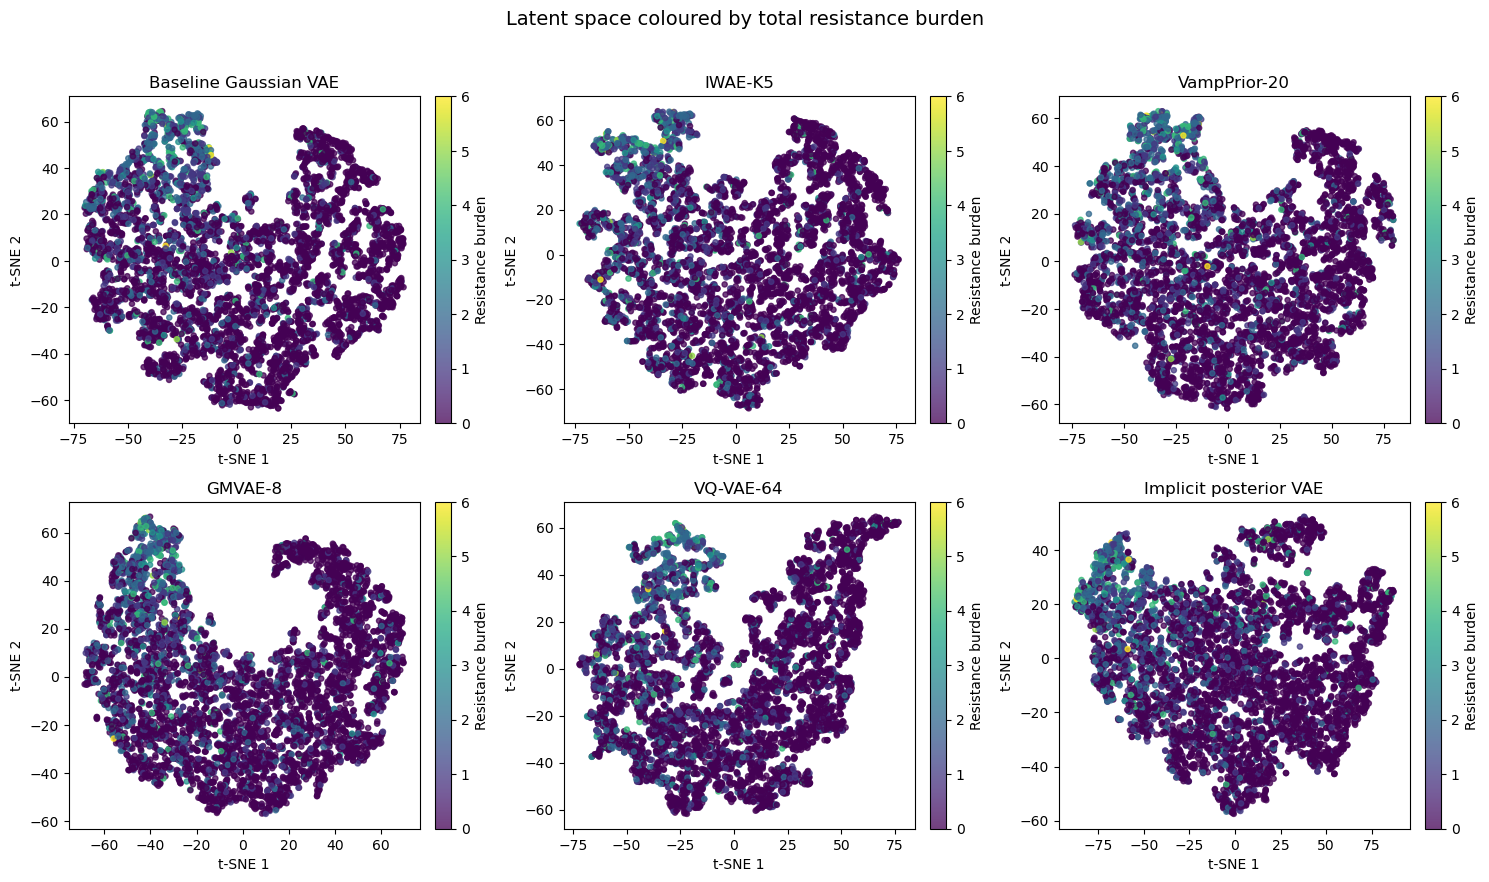

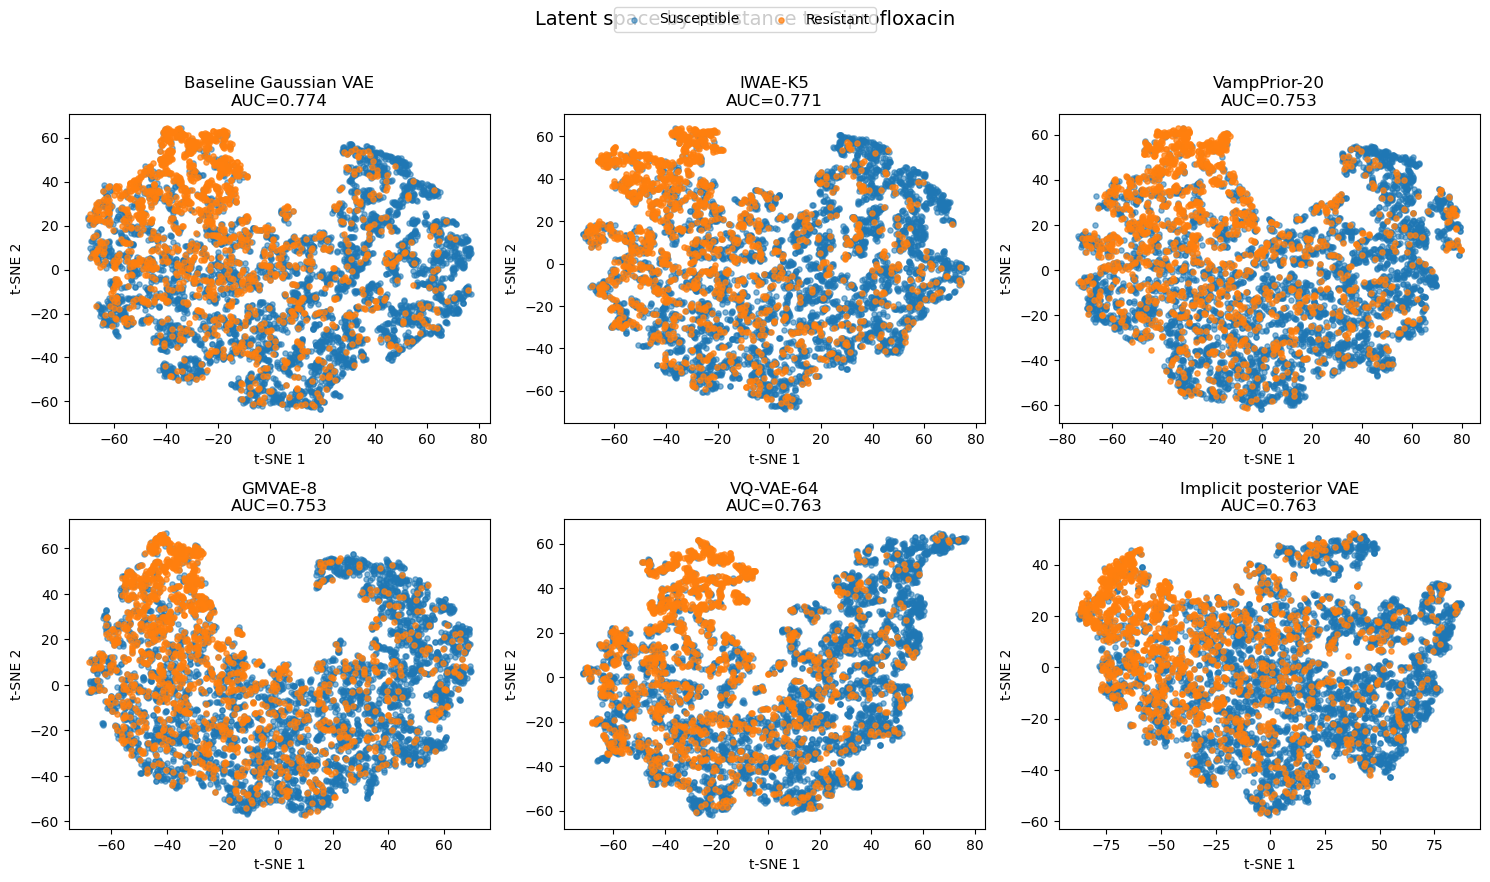

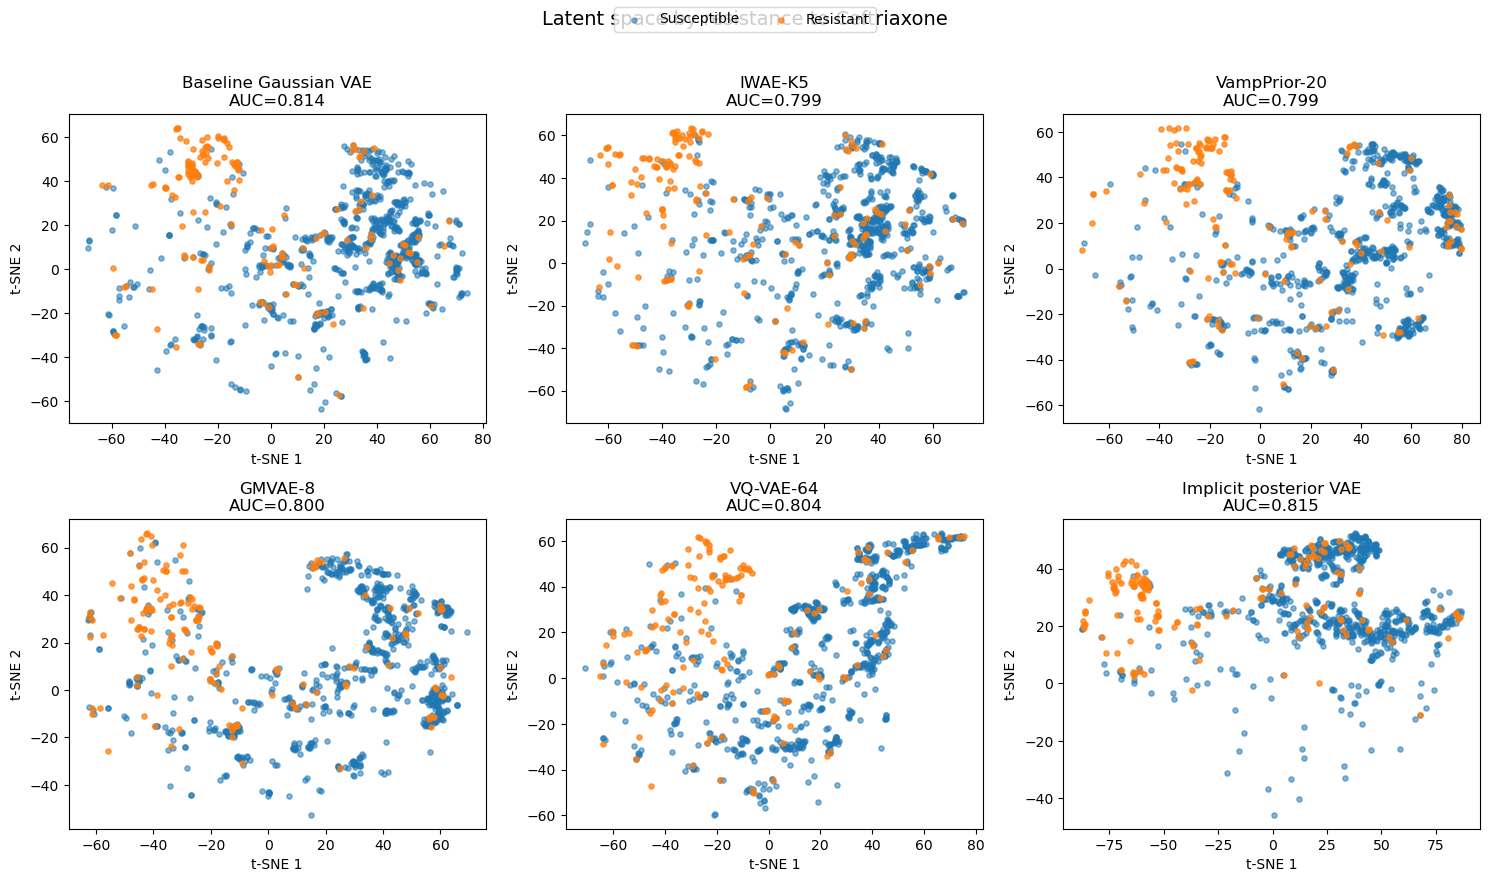

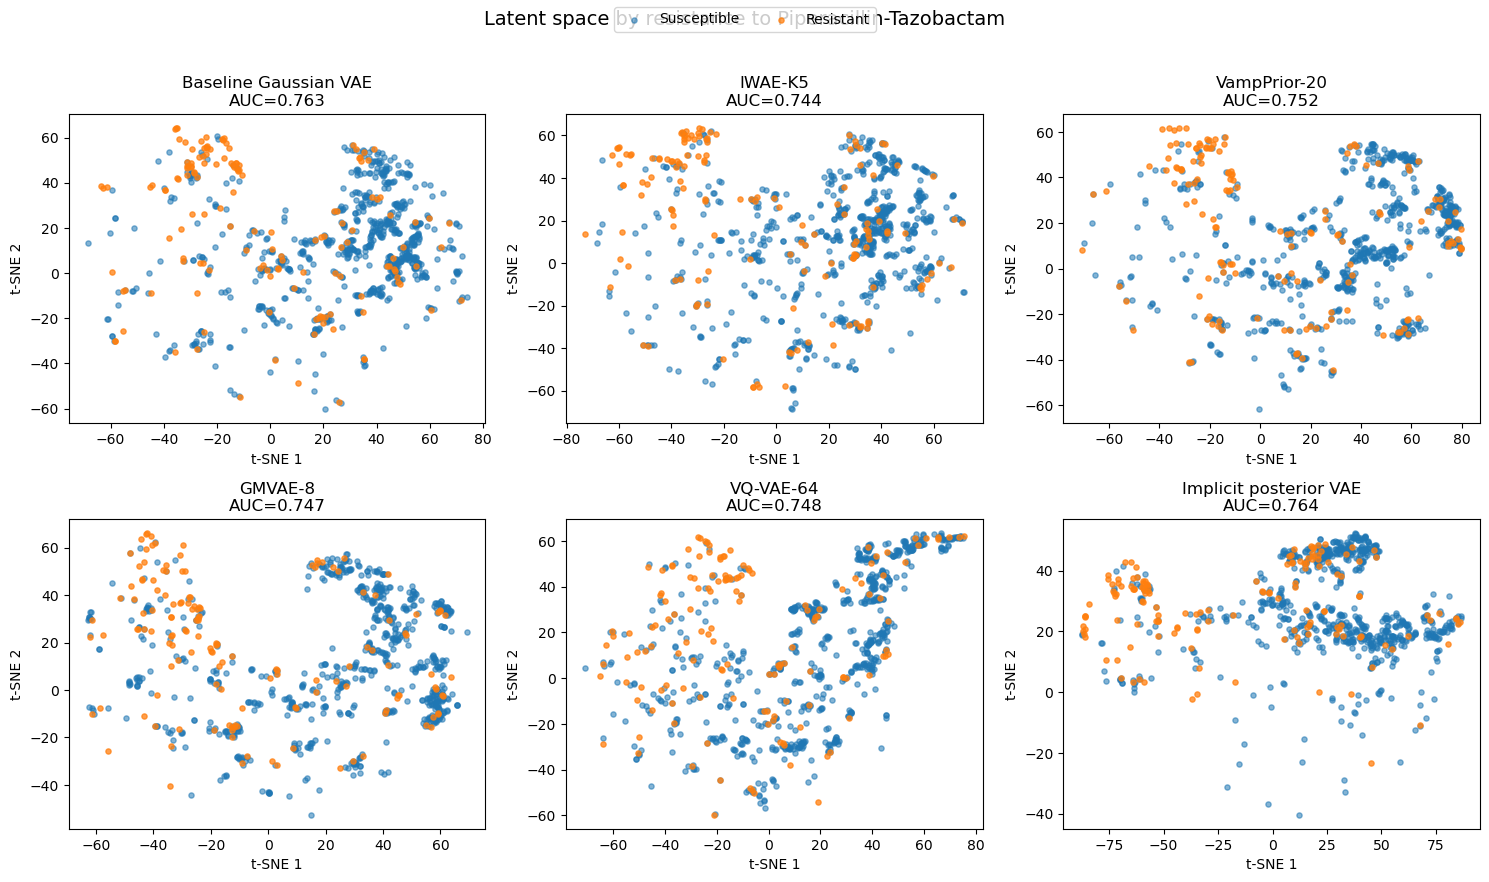

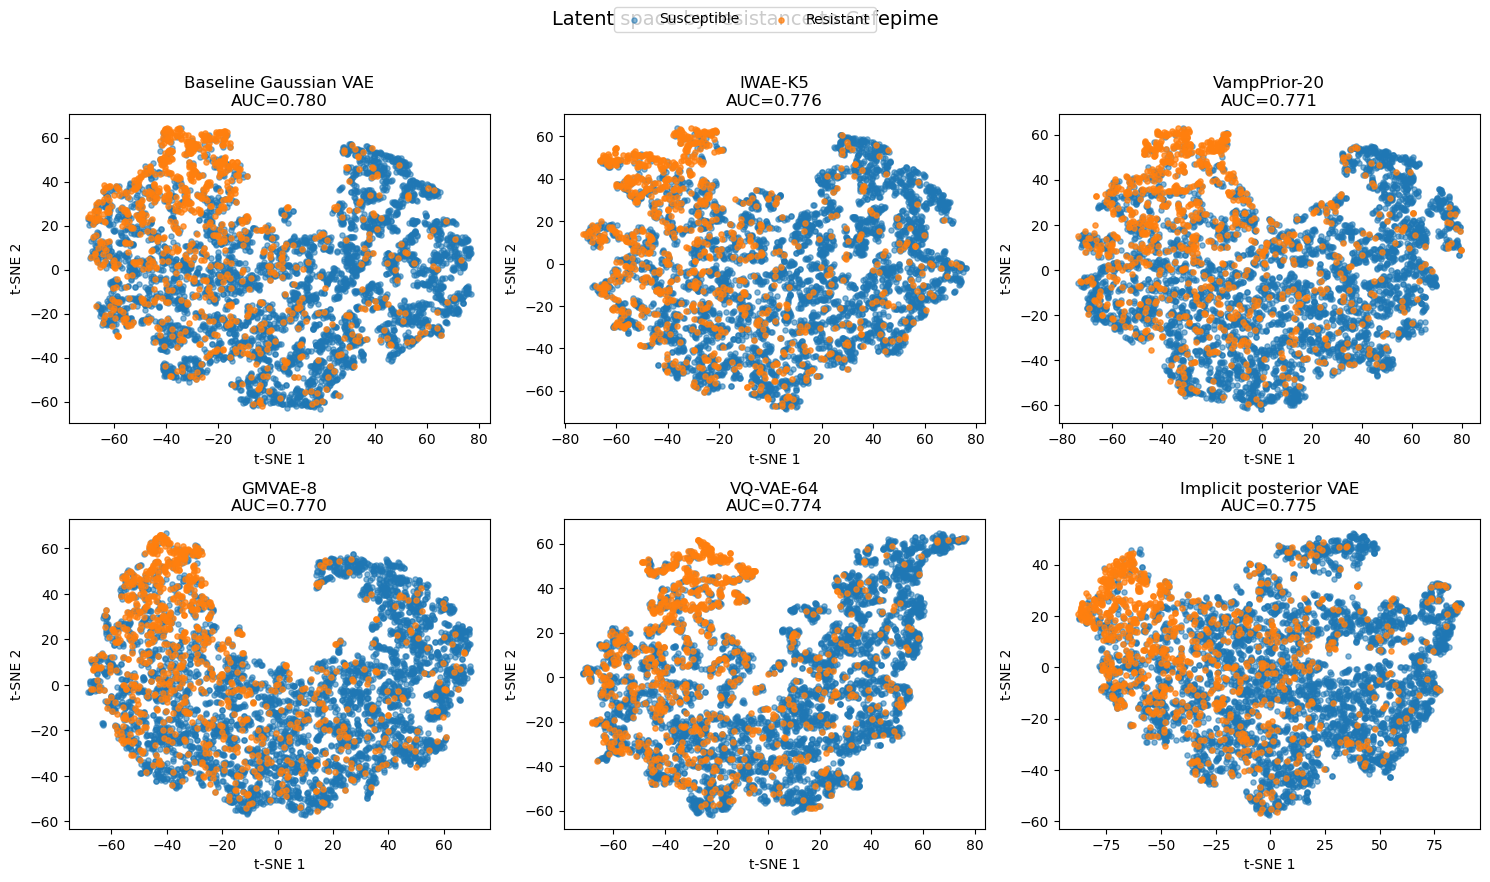

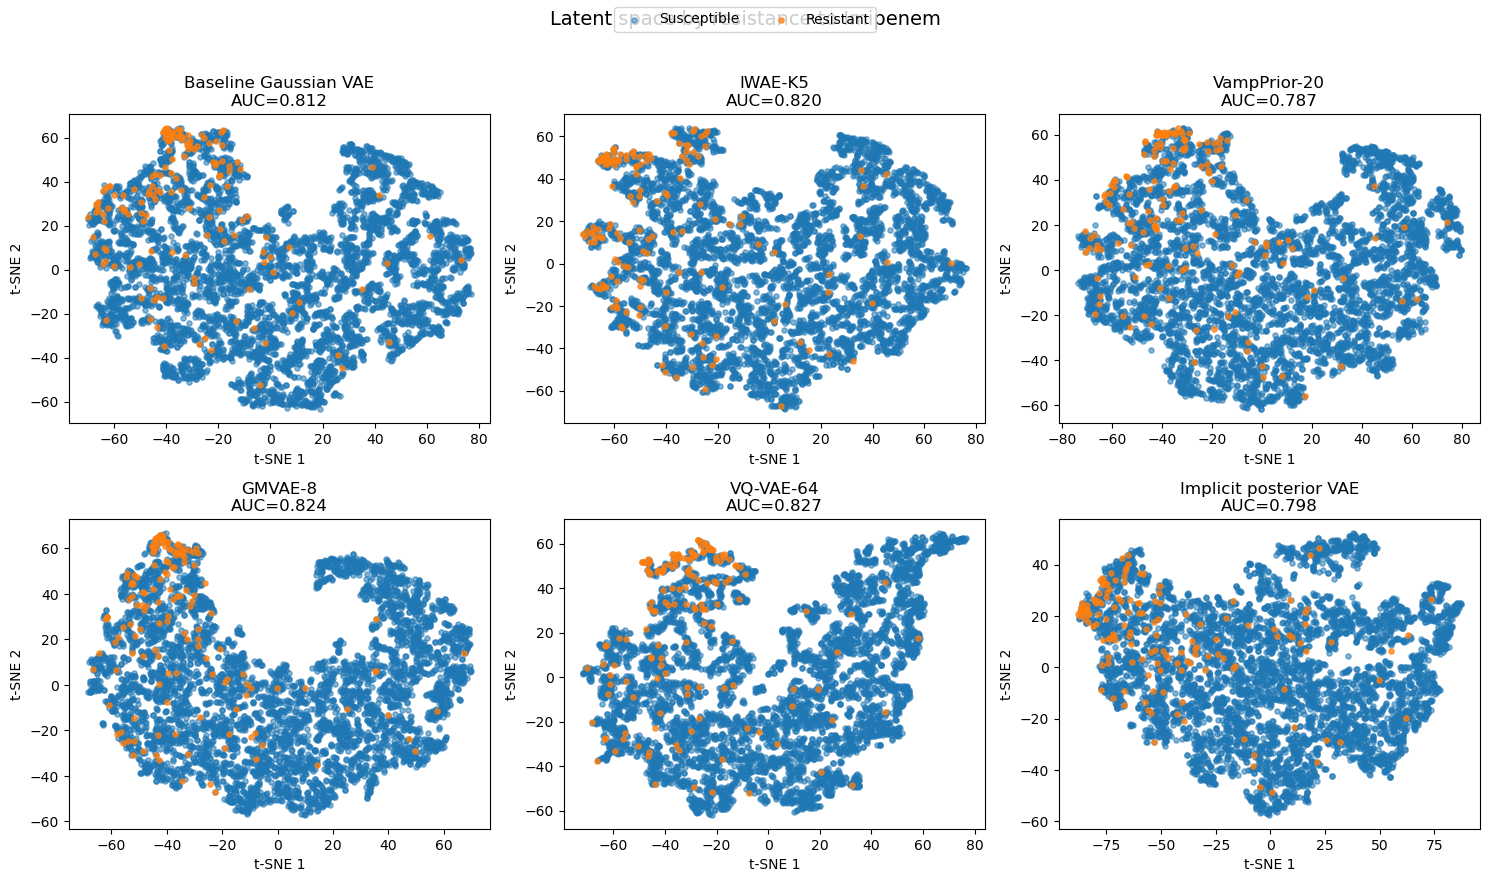

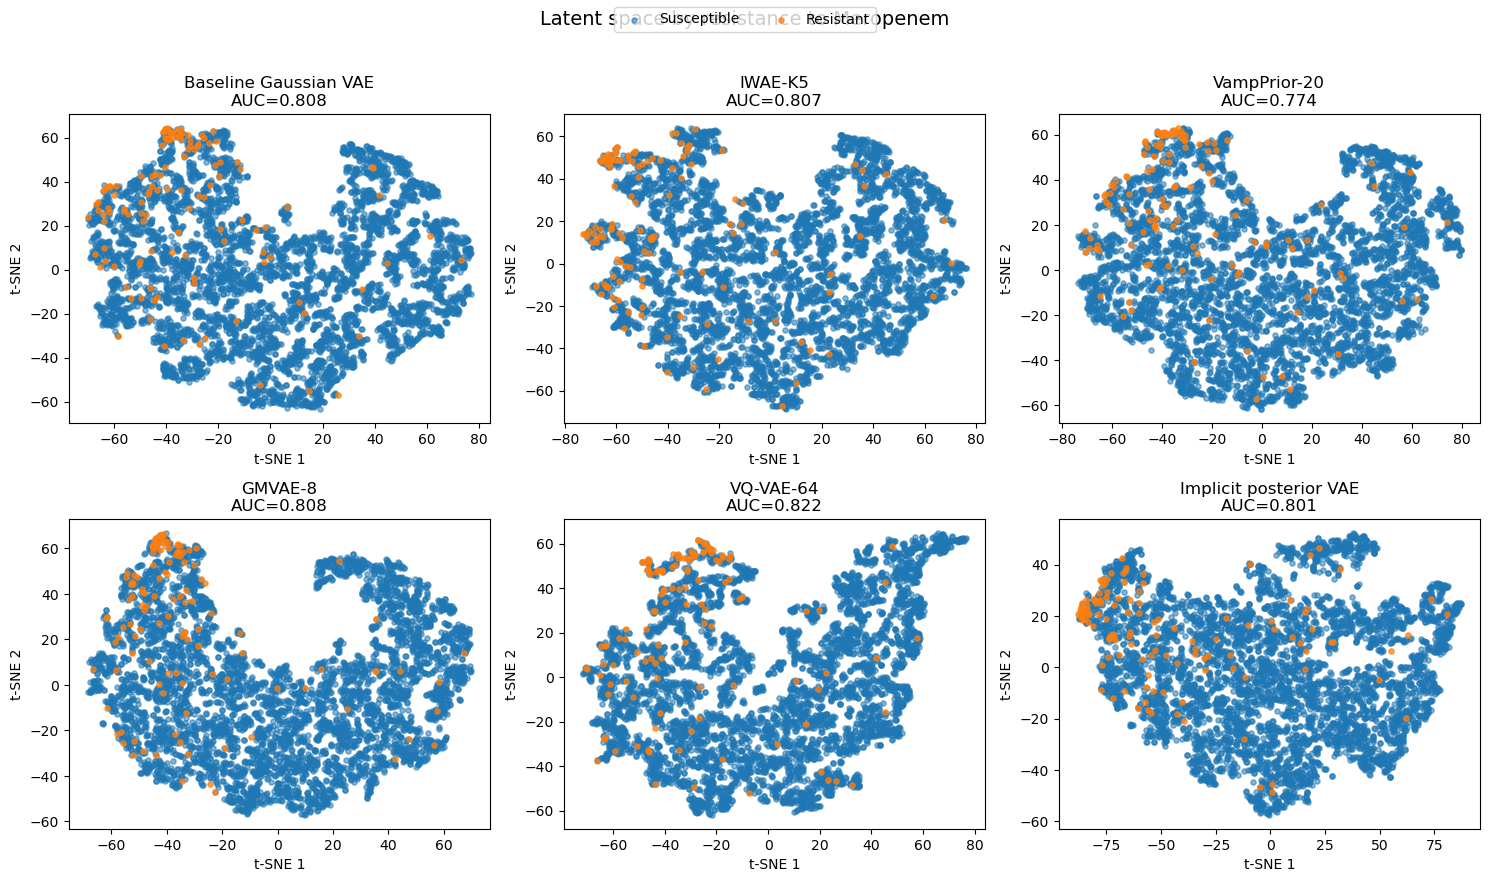

In [21]:
latent_embeddings, latent_outputs = compute_latent_embeddings_for_results(
    all_trained_results(),
    test_loader,
    perplexity=TSNE_PERPLEXITY,
    n_iter=TSNE_N_ITER,
)

plot_latent_panels_by_resistance_burden(latent_embeddings, latent_outputs)

for antibiotic in TARGET_ANTIBIOTICS:
    plot_latent_panels_by_antibiotic(latent_embeddings, latent_outputs, antibiotic)


## 16. Quantitative latent separability summary

The t-SNE figures are useful for interpretation, but visual inspection can be subjective. As a compact numerical companion, we compute per-method and per-antibiotic AUC again from the stored predictions and present it in long format.

This table is helpful when discussing whether an apparent visual separation corresponds to actual predictive performance.


In [22]:
latent_auc_rows = []
for result in all_trained_results():
    for antibiotic in TARGET_ANTIBIOTICS:
        latent_auc_rows.append(
            {
                "Model": result["name"],
                "Antibiotic": antibiotic,
                "Test AUC": result["test_aucs"][antibiotic],
                "Global test AUC": result["test_global_auc"],
            }
        )

try:
    import pandas as pd

    latent_auc_df = pd.DataFrame(latent_auc_rows)
    display(latent_auc_df.pivot(index="Model", columns="Antibiotic", values="Test AUC"))
except ImportError:
    for row in latent_auc_rows:
        print(row)


Antibiotic,Cefepime,Ceftriaxone,Ciprofloxacin,Imipenem,Meropenem,Piperacillin-Tazobactam
Model,,,,,,
Baseline Gaussian VAE,0.779781,0.813543,0.773820,0.812351,0.808176,0.763332
GMVAE-8,0.769756,0.799988,0.753133,0.824209,0.807882,0.747488
IWAE-K5,0.775602,0.798650,0.770592,0.820394,0.807461,0.744105
Implicit posterior VAE,0.774637,0.815269,0.762524,0.798337,0.800915,0.764012
VQ-VAE-64,0.773961,0.803869,0.762543,0.826963,0.822295,0.748118
VampPrior-20,0.771299,0.799334,0.752805,0.786608,0.774076,0.751705


## 17. Final conclusions after running the experiments

The objective of this project was to compare a baseline resistance-oriented VAE with several advanced VAE variants on a real MALDI-TOF antimicrobial resistance prediction task. The main evaluation criterion was held-out test global AUC, with model selection performed only on validation global AUC.

The baseline Gaussian VAE obtained the best held-out test performance:

$$
\text{Test global AUC}_{baseline}=0.8558.
$$

The advanced variants did not improve the global test AUC:

| Model | Best validation AUC | Test global AUC |
|---|---:|---:|
| Baseline Gaussian VAE | 0.8692 | 0.8558 |
| VQ-VAE-64 | 0.8667 | 0.8513 |
| Implicit posterior VAE | 0.8661 | 0.8503 |
| IWAE-K5 | 0.8694 | 0.8503 |
| GMVAE-8 | 0.8643 | 0.8474 |
| VampPrior-20 | 0.8646 | 0.8415 |

Therefore, the answer to the central project question is that, in this dataset and with this experimental configuration, the advanced VAE modifications did **not** improve the overall AMR prediction AUC over the baseline VAE. This is still an informative result: a more expressive generative model is not automatically better for the downstream supervised biological task.

### Predictive performance

The baseline was the best model globally, but the per-antibiotic results show a better picture. VQ-VAE improved the AUC for the carbapenems:

- Imipenem: baseline `0.8124`, VQ-VAE `0.8270`.
- Meropenem: baseline `0.8082`, VQ-VAE `0.8223`.

The implicit posterior VAE slightly improved Ceftriaxone and Piperacillin-Tazobactam:

- Ceftriaxone: baseline `0.8135`, implicit posterior `0.8153`.
- Piperacillin-Tazobactam: baseline `0.7633`, implicit posterior `0.7640`.

However, these local improvements were not enough to compensate for drops in other antibiotics, so the global AUC remained highest for the baseline.

### Generative/reconstruction performance

The reconstruction metrics tell a different story from the AUC results. VQ-VAE produced the best spectrum reconstruction:

| Model | MSE | MAE | Cosine similarity |
|---|---:|---:|---:|
| VQ-VAE-64 | 0.1413 | 0.3173 | 0.4721 |
| IWAE-K5 | 0.1619 | 0.3409 | 0.4288 |
| Baseline Gaussian VAE | 0.2057 | 0.3916 | 0.4207 |

This suggests that the discrete codebook learned useful recurrent spectral prototypes. Biologically, this is plausible because MALDI-TOF spectra often contain repeated species-, lineage- or phenotype-associated patterns. However, better reconstruction did not translate into better global AMR prediction. This indicates a trade-off: the best generative representation of the spectrum is not necessarily the best representation for predicting resistance.

### Why did the advanced VAEs not improve the global AUC?

There are several plausible explanations.

First, the baseline may already be well matched to the signal available in the data. The Gaussian latent space, combined with supervised AMR loss and a weak reconstruction constraint, may be flexible enough for this task. If the predictive AMR signal in MALDI-TOF spectra is relatively weak, noisy or indirect, increasing the complexity of the prior/posterior may not create new information.

Second, the advanced methods optimize generative structure, not necessarily discriminative AUC. IWAE tightens the likelihood bound, VampPrior and GMVAE make the prior more flexible, VQ-VAE improves discrete reconstruction, and the implicit posterior increases posterior flexibility. These changes can improve modelling of $p(x)$ or the latent geometry without improving $p(y\mid x)$. In this project, the target metric is AMR prediction, so generative improvements only help if they preserve or amplify resistance-relevant variation.

Third, resistance biology may be only partially visible in MALDI-TOF spectra. Many AMR mechanisms are genetic or regulatory, such as beta-lactamases, carbapenemases, porin loss, target mutations or efflux regulation. These mechanisms do not always create a strong, direct and consistent mass-spectral signature. The spectrum may capture lineage or strain background correlated with resistance, but this correlation can be heterogeneous across antibiotics and datasets.

Fourth, the more complex models may require stronger tuning. VampPrior became numerically unstable and produced `nan` losses after epoch 8, suggesting that the flexible learned prior can be harder to train. GMVAE also showed less stable loss behaviour. These models introduce extra parameters and optimization difficulties, so they may need different learning rates, gradient clipping, stronger variance constraints, more careful initialization or longer tuning.

Fifth, the validation and test results show mild overfitting or model-selection mismatch. IWAE achieved the best validation AUC (`0.8694`) but did not improve test AUC (`0.8503`). This suggests that small validation gains are not necessarily robust. The baseline may generalize better because it is simpler and less sensitive to noise in the validation split.

Finally, the dataset contains many missing AMR labels. The masked loss handles missingness correctly, but each antibiotic is effectively trained on a different subset of isolates. This can make the multi-antibiotic objective noisy and can reduce the benefit of more expressive latent-variable models.

## 21. Baseline spectrum reconstruction examples

These plots compare real and reconstructed spectra:

$$
x \rightarrow w \rightarrow \hat{x}.
$$

Because `w` is resistance-oriented, we do not expect perfect reconstruction. The purpose is to check whether the model still preserves broad spectral structure while prioritising AMR prediction.


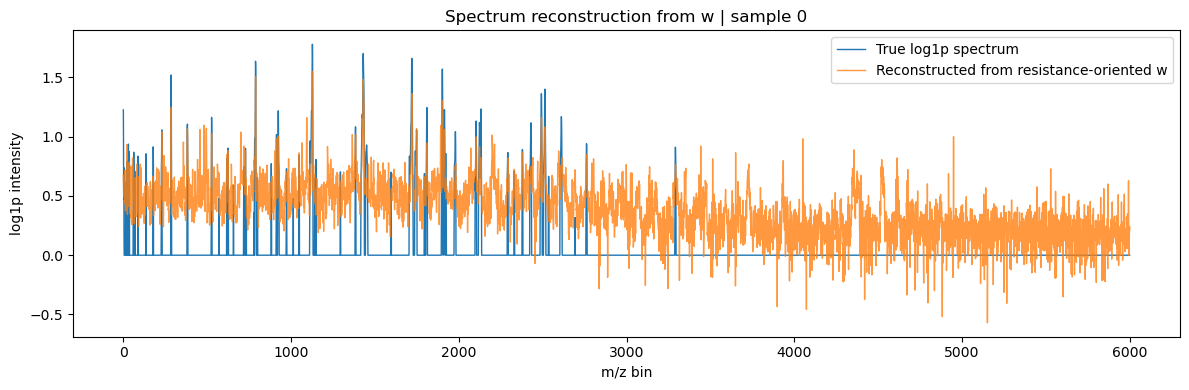

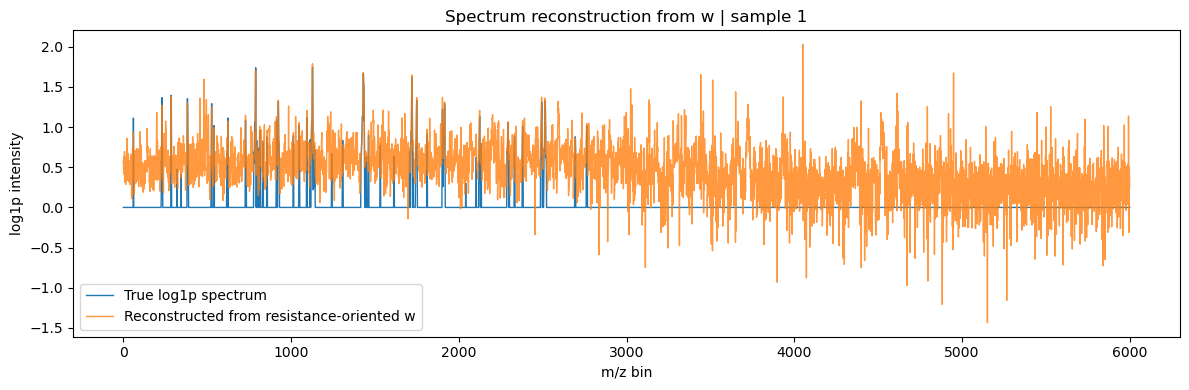

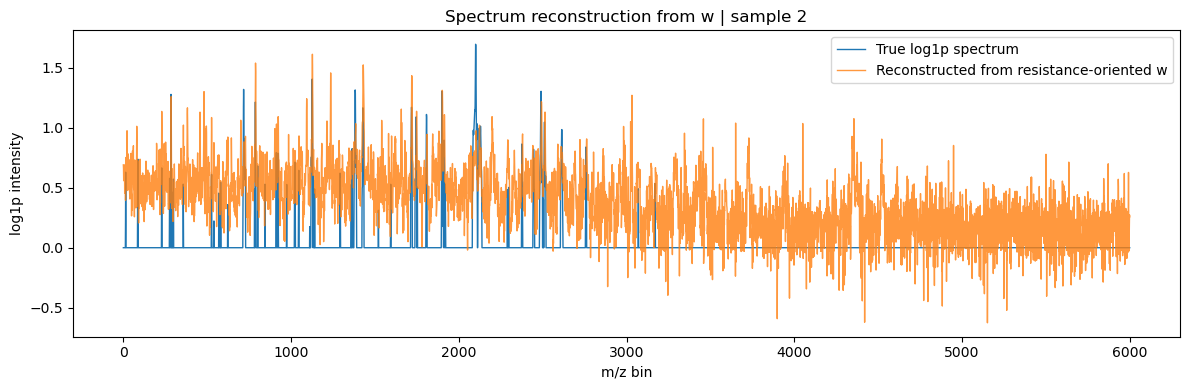

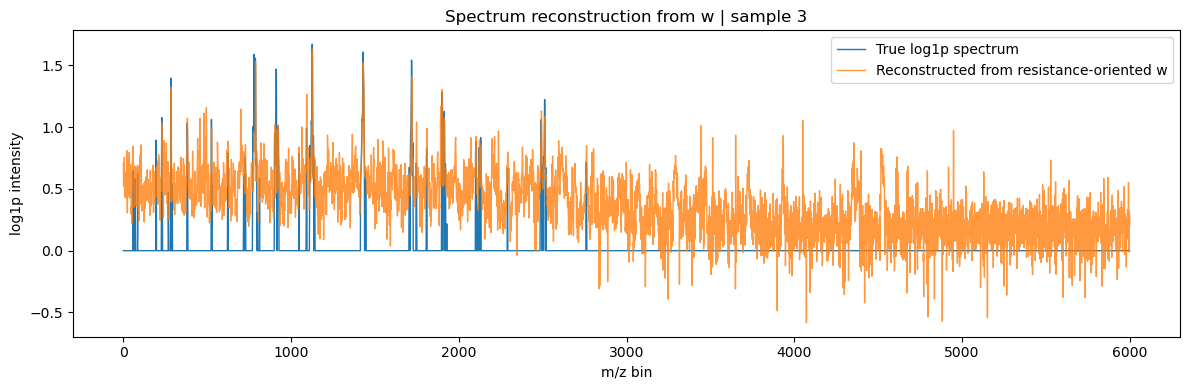

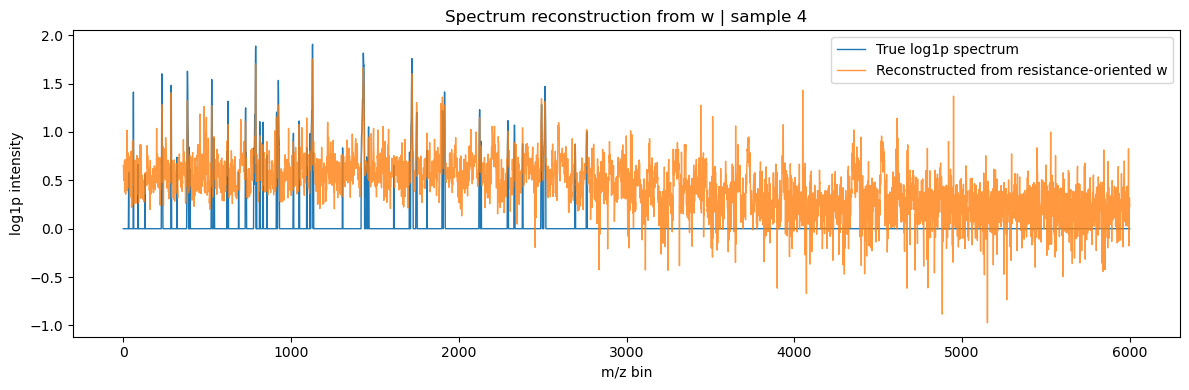

In [26]:
def plot_spectrum_reconstruction(test_out, sample_idx=0):
    x_true = test_out["x_true"][sample_idx]
    x_rec = test_out["x_mu"][sample_idx]

    plt.figure(figsize=(12, 4))
    plt.plot(x_true, label="True log1p spectrum", linewidth=1)
    plt.plot(x_rec, label="Reconstructed from resistance-oriented w", linewidth=1, alpha=0.8)
    plt.xlabel("m/z bin")
    plt.ylabel("log1p intensity")
    plt.title(f"Spectrum reconstruction from w | sample {sample_idx}")
    plt.legend()
    plt.tight_layout()
    plt.show()


for idx in range(min(5, len(test_out["x_true"]))):
    plot_spectrum_reconstruction(test_out, sample_idx=idx)
